<a href="https://colab.research.google.com/github/Titli-17/Hybrid-Movie-Recommendation-System/blob/main/Movie_Recommendation_Sys_Collaborative_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np

In [43]:
with open('/tools/moviedata.csv') as f:
    print(f.readline())

movieId,title,genres



In [44]:
with open('/tools/ratings.csv') as f:
    print(f.readline())

userId,movieId,rating,timestamp



In [45]:
movies_df = pd.read_csv('/tools/moviedata.csv',usecols=['movieId','title'],dtype={'movieId': 'int32', 'title': 'str'})
movies_df.head()

,movieId,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3,Grumpier Old Men (1995)
3,4,Waiting to Exhale (1995)
4,5,Father of the Bride Part II (1995)


In [46]:

# Load dataset
movies = pd.read_csv("/tools/moviedata.csv")


# Split and count genres


genre_counts = {}

for genres in movies['genres']:
    # Split multiple genres
    for g in genres.split('|'):
        if g in genre_counts:
            genre_counts[g] += 1
        else:
            genre_counts[g] = 1

# Convert to DataFrame
genre_df = pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Count'])

# Sort by count
genre_df = genre_df.sort_values(by='Count', ascending=False)

print("Genre Distribution:\n")
print(genre_df)

Genre Distribution:

                                         Genre  Count
11                                       Drama   1053
4                                       Comedy    946
35                                Comedy,Drama    435
2                               Comedy,Romance    363
14                               Drama,Romance    349
..                                         ...    ...
486                     Children,Drama,Musical      1
483    Adventure,Drama,Horror,Mystery,Thriller      1
482  Adventure,Children,Comedy,Fantasy,Mystery      1
481       Adventure,Animation,Children,Western      1
943            Comedy,Mystery,Romance,Thriller      1

[951 rows x 2 columns]


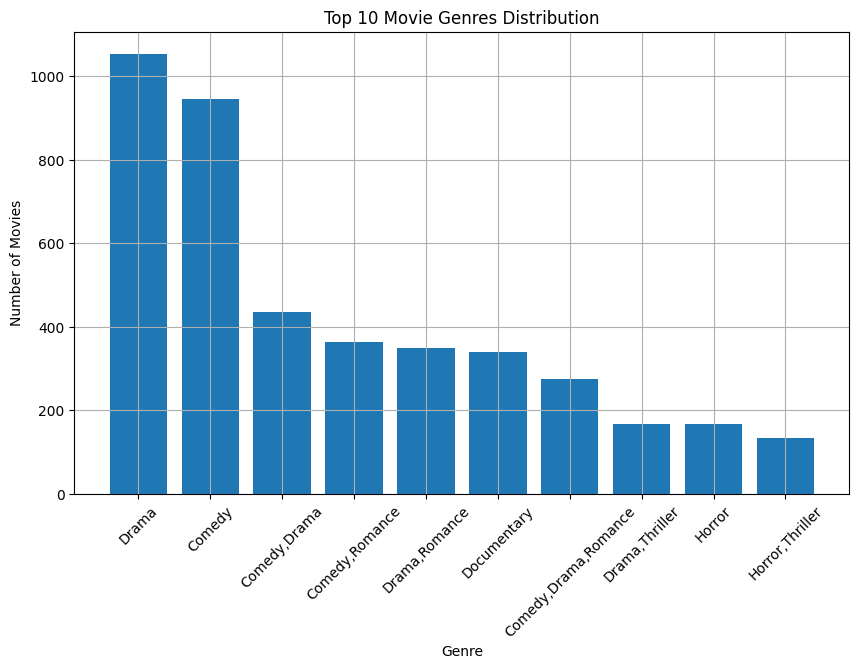

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Plot top 10 genres
plt.bar(genre_df['Genre'][:10], genre_df['Count'][:10])

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title("Top 10 Movie Genres Distribution")

plt.xticks(rotation=45)
plt.grid()

plt.savefig("genre_distribution.png")
plt.show()

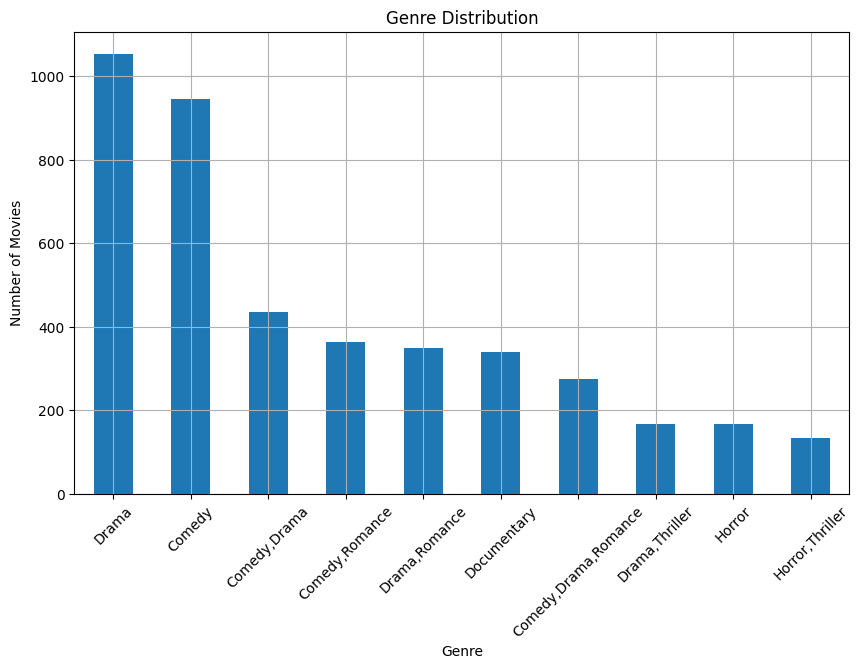

In [48]:
plt.figure(figsize=(10,6))

genre_df.set_index('Genre')['Count'].head(10).plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title("Genre Distribution")

plt.xticks(rotation=45)
plt.grid()

plt.savefig("genre_distribution.png")
plt.show()

In [49]:
ratings_df=pd.read_csv('/tools/ratings.csv',usecols=['userId', 'movieId', 'rating'],
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})
ratings_df.head()

,userId,movieId,rating
0,1,1,4.000
1,1,3,4.000
2,1,6,4.000
3,1,47,5.000
4,1,50,5.000


Ratings Frequency Table:

rating
0.500     1370
1.000     2811
1.500     1791
2.000     7551
2.500     5550
3.000    20047
3.500    13136
4.000    26818
4.500     8551
5.000    13211
Name: count, dtype: int64


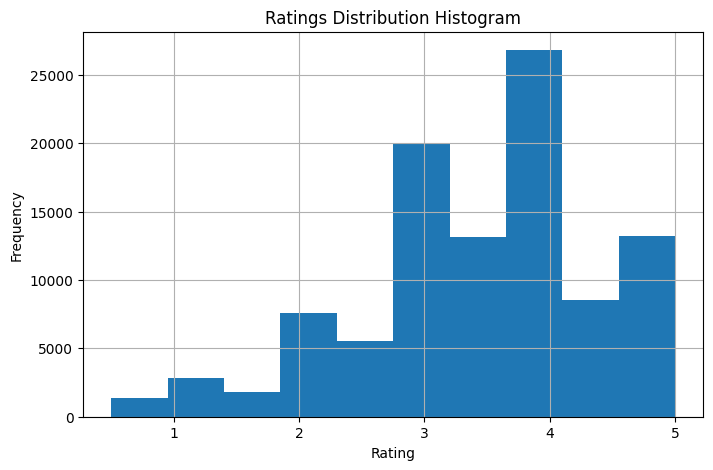

In [50]:

import matplotlib.pyplot as plt

# Step 1: Frequency Calculation

# Count frequency of each rating
frequency = ratings_df['rating'].value_counts().sort_index()

print("Ratings Frequency Table:\n")
print(frequency)

# Step 2: Plot Histogram


plt.figure(figsize=(8,5))
plt.hist(ratings_df['rating'], bins=10)

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Ratings Distribution Histogram")

plt.grid()
plt.savefig("ratings_distribution.png")
plt.show()

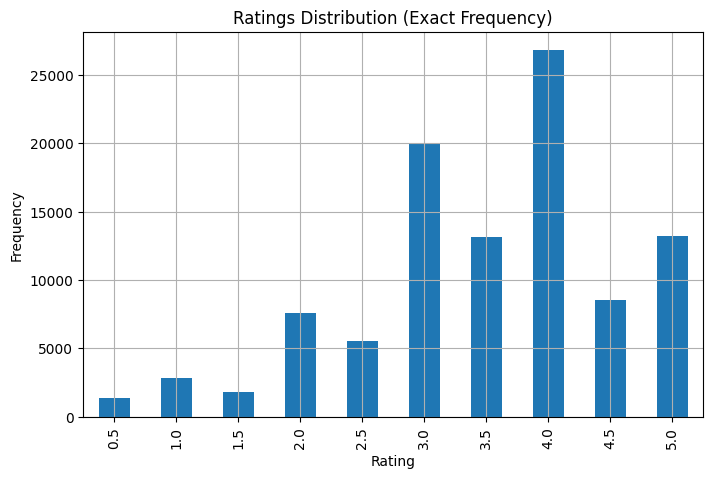

In [51]:
plt.figure(figsize=(8,5))

frequency.plot(kind='bar')

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Ratings Distribution (Exact Frequency)")

plt.grid()
plt.savefig("ratings_bar.png")
plt.show()

In [52]:
df = pd.merge(ratings_df,movies_df,on='movieId')
df.head()

,userId,movieId,rating,title
0,1,1,4.000,Toy Story (1995)
1,1,3,4.000,Grumpier Old Men (1995)
2,1,6,4.000,Heat (1995)
3,1,47,5.000,Seven (a.k.a. Se7en) (1995)
4,1,50,5.000,"Usual Suspects, The (1995)"


In [53]:
combine_movie_rating = df.dropna(axis = 0, subset = ['title'])
movie_ratingCount = (combine_movie_rating.
     groupby(by = ['title'])['rating'].
     count().
     reset_index().
     rename(columns = {'rating': 'totalRatingCount'})
     [['title', 'totalRatingCount']]
    )
movie_ratingCount.head()

,title,totalRatingCount
0,'71 (2014),1
1,'Hellboy': The Seeds of Creation (2004),1
2,'Round Midnight (1986),2
3,'Salem's Lot (2004),1
4,'Til There Was You (1997),2


In [54]:
rating_with_totalRatingCount = combine_movie_rating.merge(movie_ratingCount, left_on = 'title', right_on = 'title', how = 'left')
rating_with_totalRatingCount.head()

,userId,movieId,rating,title,totalRatingCount
0,1,1,4.000,Toy Story (1995),215
1,1,3,4.000,Grumpier Old Men (1995),52
2,1,6,4.000,Heat (1995),102
3,1,47,5.000,Seven (a.k.a. Se7en) (1995),203
4,1,50,5.000,"Usual Suspects, The (1995)",204


In [55]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(movie_ratingCount['totalRatingCount'].describe())

count   9719.000
mean      10.375
std       22.406
min        1.000
25%        1.000
50%        3.000
75%        9.000
max      329.000
Name: totalRatingCount, dtype: float64


In [56]:
popularity_threshold = 50
rating_popular_movie= rating_with_totalRatingCount.query('totalRatingCount >= @popularity_threshold')
rating_popular_movie.head()

,userId,movieId,rating,title,totalRatingCount
0,1,1,4.000,Toy Story (1995),215
1,1,3,4.000,Grumpier Old Men (1995),52
2,1,6,4.000,Heat (1995),102
3,1,47,5.000,Seven (a.k.a. Se7en) (1995),203
4,1,50,5.000,"Usual Suspects, The (1995)",204


In [57]:
rating_popular_movie.shape

(41362, 5)

In [58]:
movie_features_df=rating_popular_movie.pivot_table(index='title',columns='userId',values='rating').fillna(0)
movie_features_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
10 Things I Hate About You (1999),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,3.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000
12 Angry Men (1957),0.000,0.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2001: A Space Odyssey (1968),0.000,0.000,0.000,0.000,0.000,0.000,4.000,0.000,0.000,0.000,...,0.000,0.000,5.000,0.000,0.000,5.000,0.000,3.000,0.000,4.500
28 Days Later (2002),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.500,0.000,5.000
300 (2007),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,...,0.000,0.000,0.000,0.000,3.000,0.000,0.000,5.000,0.000,4.000


User Activity (Number of Ratings per User):

userId
1    232
2     29
3     39
4    216
5     44
dtype: int64

User Activity Frequency Table:

20      14
21      15
22      14
23      13
24       7
        ..
1346     1
1864     1
2108     1
2478     1
2698     1
Name: count, Length: 261, dtype: int64


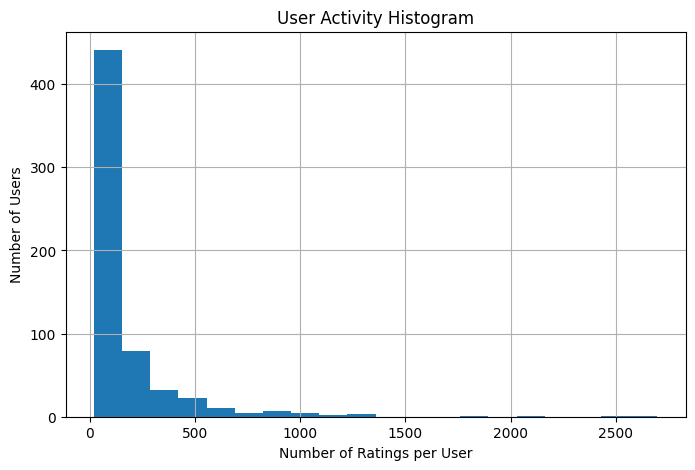

In [59]:

# Step 1: Calculate User Activity

# Count number of ratings per user
user_activity = ratings_df.groupby('userId').size()

print("User Activity (Number of Ratings per User):\n")
print(user_activity.head())

# Step 2: Frequency Distribution of User

# How many users have X number of ratings
activity_frequency = user_activity.value_counts().sort_index()

print("\nUser Activity Frequency Table:\n")
print(activity_frequency)

# -------------------------------
# Step 3: Plot Histogram
# -------------------------------

plt.figure(figsize=(8,5))
plt.hist(user_activity, bins=20)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Histogram")

plt.grid()
plt.savefig("user_activity_histogram.png")
plt.show()

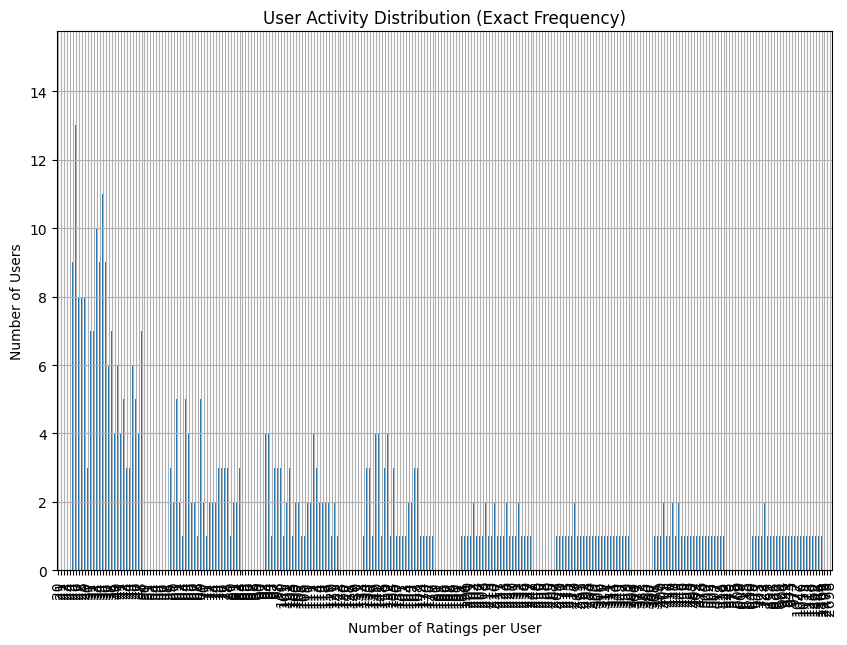

In [60]:
plt.figure(figsize=(10,7))

activity_frequency.plot(kind='bar')

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution (Exact Frequency)")

plt.grid()
plt.savefig("user_activity_bar.png")
plt.show()

In [61]:
from scipy.sparse import csr_matrix

movie_features_df_matrix = csr_matrix(movie_features_df.values)

from sklearn.neighbors import NearestNeighbors


model_knn = NearestNeighbors(metric = 'cosine', algorithm = 'brute')
model_knn.fit(movie_features_df_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [62]:
movie_features_df.shape

(450, 606)

In [63]:
query_index = np.random.choice(movie_features_df.shape[0])
print(query_index)
distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index,:].values.reshape(1, -1), n_neighbors = 6)

102


In [64]:
movie_features_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
10 Things I Hate About You (1999),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,3.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000
12 Angry Men (1957),0.000,0.000,0.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2001: A Space Odyssey (1968),0.000,0.000,0.000,0.000,0.000,0.000,4.000,0.000,0.000,0.000,...,0.000,0.000,5.000,0.000,0.000,5.000,0.000,3.000,0.000,4.500
28 Days Later (2002),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.500,0.000,5.000
300 (2007),0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,...,0.000,0.000,0.000,0.000,3.000,0.000,0.000,5.000,0.000,4.000


In [65]:
for i in range(0, len(distances.flatten())):
    if i == 0:
       print('Recommendations for {0}:\n'.format(movie_features_df.index[query_index]))
    else:
        print('{0}: {1}, with distance of {2}:'.format(i, movie_features_df.index[indices.flatten()[i]], distances.flatten()[i]))

Recommendations for Close Encounters of the Third Kind (1977):

1: 2001: A Space Odyssey (1968), with distance of 0.48768913745880127:
2: Ghostbusters (a.k.a. Ghost Busters) (1984), with distance of 0.5106353163719177:
3: Planet of the Apes (1968), with distance of 0.5211186408996582:
4: Unbreakable (2000), with distance of 0.5224233865737915:
5: E.T. the Extra-Terrestrial (1982), with distance of 0.524257481098175:


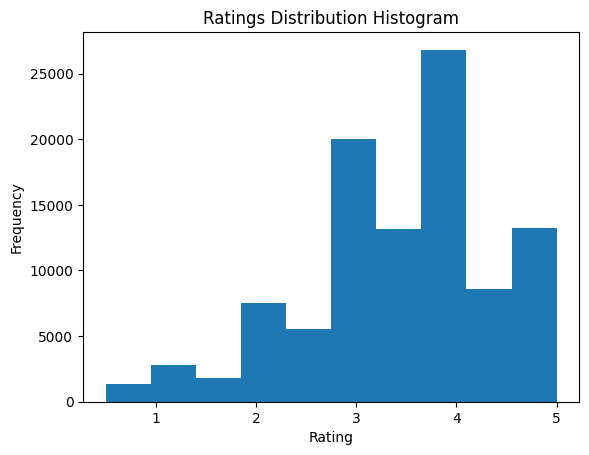

In [68]:


# Plot histogram
plt.figure()
plt.hist(ratings_df['rating'], bins=10)

# Labels and title
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Ratings Distribution Histogram")

# Save figure (for report)
plt.savefig("ratings_distribution.png")

# Show plot
plt.show()